In [11]:
import polars as pl
from pathlib import Path

ROOT = Path.cwd()
OUT_DIR = ROOT / "data" / "output"
if not OUT_DIR.exists():
    OUT_DIR = ROOT.parent / "data" / "output"

parquet_path = OUT_DIR / "forecast_seccion_1_partial.parquet"
if not parquet_path.exists():
    raise FileNotFoundError(f"Parquet file not found: {parquet_path}")

df = pl.read_parquet(parquet_path)
out = df.filter(pl.col("unique_id") == "1").select(["value", "valuehat"])
out.write_csv("forecast_seccion_1_partial_uid_1.csv")
print("Archivo generado: forecast_seccion_1_partial_uid_1.csv")

Archivo generado: forecast_seccion_1_partial_uid_1.csv


shape: (5, 3)
┌────────────┬───────────┬──────────┐
│ ds         ┆ value     ┆ valuehat │
│ ---        ┆ ---       ┆ ---      │
│ date       ┆ f64       ┆ f64      │
╞════════════╪═══════════╪══════════╡
│ 2024-05-26 ┆ 2134653.8 ┆ 2.0427e6 │
│ 2024-05-27 ┆ 1.9304e6  ┆ 2.0117e6 │
│ 2024-05-28 ┆ 2.0906e6  ┆ 2.2787e6 │
│ 2024-05-29 ┆ 1.8514e6  ┆ 1.9099e6 │
│ 2024-05-30 ┆ 1.7116e6  ┆ 1.8177e6 │
└────────────┴───────────┴──────────┘


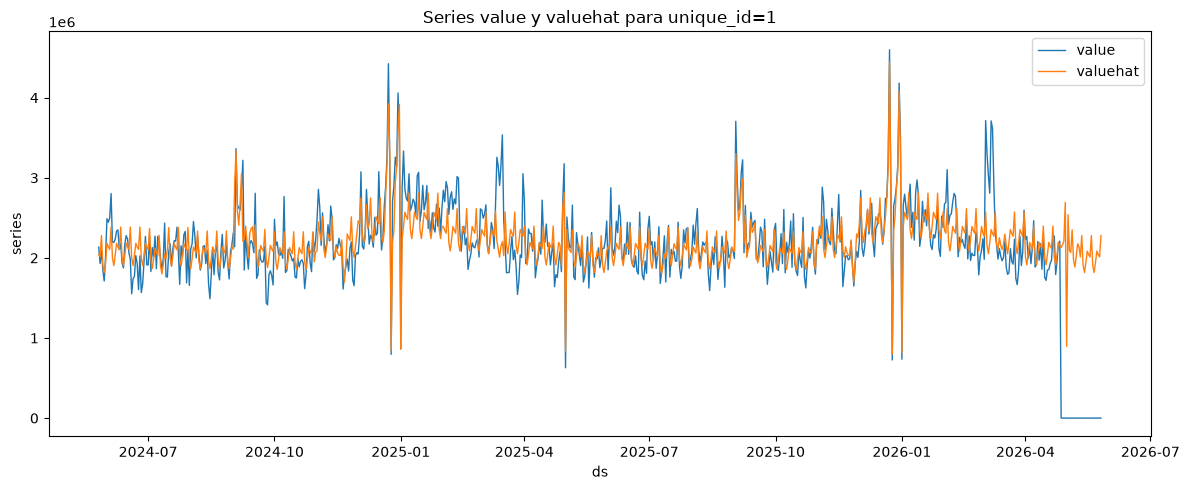

In [12]:
import matplotlib.pyplot as plt


def graph_plot(filtered: pl.DataFrame):
    x = filtered["ds"].to_list()
    y_value = filtered["value"].to_list()
    y_valuehat = filtered["valuehat"].to_list()

    plt.figure(figsize=(12, 5))
    plt.plot(x, y_value, label="value", linewidth=1)
    plt.plot(x, y_valuehat, label="valuehat", linewidth=1)
    plt.xlabel("ds")
    plt.ylabel("series")
    plt.title("Series value y valuehat para unique_id=1")
    plt.legend()
    plt.tight_layout()
    plt.show()


filtered = (
    df.filter(pl.col("unique_id") == "1").select(["ds", "value", "valuehat"]).sort("ds")
)

print(filtered.head())

graph_plot(filtered)

In [13]:
# Mostrar cantidad de filas por cada unique_id
counts = (
    df.group_by("unique_id")
    .agg(pl.len().alias("n_rows"))
    .sort("n_rows", descending=True)
)
print(counts.head(10))

shape: (10, 2)
┌──────────────────────┬────────┐
│ unique_id            ┆ n_rows │
│ ---                  ┆ ---    │
│ str                  ┆ u32    │
╞══════════════════════╪════════╡
│ 1||T:00063||S:403948 ┆ 731    │
│ 1||T:00003||S:494265 ┆ 731    │
│ 1||T:00411||S:246508 ┆ 731    │
│ 1||T:00411||S:473929 ┆ 731    │
│ 1||T:00411||S:545629 ┆ 731    │
│ 1||T:00154||S:129597 ┆ 731    │
│ 1||T:00025||S:514412 ┆ 731    │
│ 1||S:557116          ┆ 731    │
│ 1||T:00063||S:508233 ┆ 731    │
│ 1||T:00211||S:414788 ┆ 731    │
└──────────────────────┴────────┘


In [14]:
wmape_path = OUT_DIR / "wmape.parquet"

df_wmape = pl.read_parquet(wmape_path)
df_wmape.filter(
    (pl.col("wmape") != 0) & pl.col("unique_id").str.starts_with("1||")
).sort("wmape", descending=False)

unique_id,wmape,bias,n_points,sum_y,sum_yhat
str,f64,f64,u32,f64,f64
"""1||T:00063""",0.12822,-0.006003,697,800781.19,795974.0
"""1||T:00154""",0.139796,-0.001918,701,730822.64,729421.0
"""1||T:00003||S:336865""",0.142857,-0.142857,4,7.0,6.0
"""1||S:336865""",0.142857,-0.142857,4,7.0,6.0
"""1||S:10578""",0.142857,0.142857,3,7.0,8.0
…,…,…,…,…,…
"""1||T:00025||S:286751""",32.0,-32.0,1,1.0,-31.0
"""1||T:00411||S:214295""",34.75,-34.75,4,4.0,-135.0
"""1||T:00025||S:493808""",35.333333,-35.333333,3,3.0,-103.0


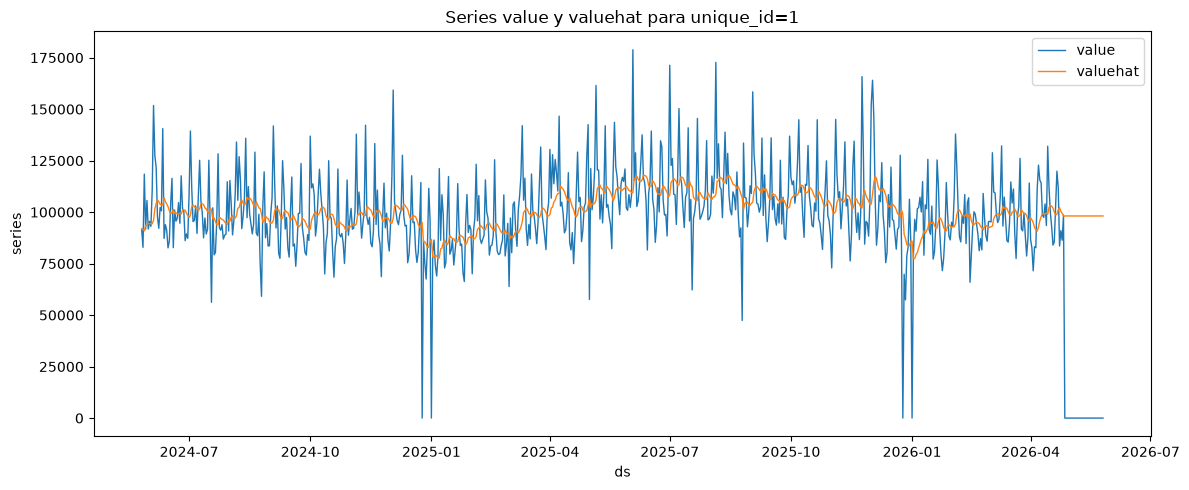

In [15]:
filtered = (
    df.filter(pl.col("unique_id") == "1||T:00063")
    .select(["ds", "value", "valuehat"])
    .sort("ds")
)

graph_plot(filtered)

In [17]:
df.filter(
    (pl.col("unique_id") == "1||T:00063") & (pl.col("period_type") == "forecast_only")
).sort("ds")

unique_id,ds,value,valuehat,y,yhat,train_start,train_end,test_start,test_end,forecast_start,forecast_end,sku_desc,store_name,seccion,period_type,driver_effect,driver_effect_value,conteo_sku,intercept,asp,edp,discount,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weekday_7,month_10,month_11,month_12,month_2,month_3,month_4,month_5,month_6,…,promo_mar_+2,promo_mar_+0,promo_mar_+5,promo_mar_-1,promo_mar_+4,promo_sep_+4,promo_sep_+2,promo_sep_+0,promo_sep_+9,promo_sep_+1,promo_sep_-1,promo_sep_+12,promo_sep_+13,promo_sep_+15,promo_sep_+6,promo_sep_+11,promo_sep_+8,promo_sep_+10,promo_sep_+14,promo_sep_+7,promo_sep_+5,promo_sep_+3,promo_nov_-3,promo_nov_-1,promo_nov_+0,promo_nov_-2,promo_dic_-1,promo_dic_+0,promo_dic_+1,fathers_day,black_friday_-3,black_friday_-5,black_friday_-1,black_friday_+0,black_friday_-6,black_friday_-2,black_friday_-4
str,date,f64,f64,f64,f64,date,date,date,date,date,date,str,str,str,str,f64,f64,i64,i32,f64,f64,f64,u8,u8,u8,u8,u8,u8,i32,i32,i32,i32,i32,u8,i32,i32,…,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f64,i8,i8,i8,i8,i8,i8,i8
"""1||T:00063""",2026-04-27,0.0,98140.31,0.0,1161.0,2024-05-26,2026-03-29,2026-03-30,2026-04-26,2026-04-27,2026-05-26,"""""","""CARRUSEL""","""1""","""forecast_only""",-0.158709,-0.151994,0,1,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0
"""1||T:00063""",2026-04-28,0.0,98140.33,0.0,1161.0,2024-05-26,2026-03-29,2026-03-30,2026-04-26,2026-04-27,2026-05-26,"""""","""CARRUSEL""","""1""","""forecast_only""",-0.164536,-0.135876,0,1,0.0,0.0,0.0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0
"""1||T:00063""",2026-04-29,0.0,98140.35,0.0,1161.0,2024-05-26,2026-03-29,2026-03-30,2026-04-26,2026-04-27,2026-05-26,"""""","""CARRUSEL""","""1""","""forecast_only""",-0.129969,-0.114963,0,1,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0
"""1||T:00063""",2026-04-30,0.0,98140.55,0.0,1161.0,2024-05-26,2026-03-29,2026-03-30,2026-04-26,2026-04-27,2026-05-26,"""""","""CARRUSEL""","""1""","""forecast_only""",0.079016,0.082295,0,1,0.0,0.0,0.0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0
"""1||T:00063""",2026-05-01,0.0,98139.44,0.0,1160.0,2024-05-26,2026-03-29,2026-03-30,2026-04-26,2026-04-27,2026-05-26,"""""","""CARRUSEL""","""1""","""forecast_only""",-1.032748,-1.018485,0,1,0.0,0.0,0.0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""1||T:00063""",2026-05-22,0.0,98140.22,0.0,1161.0,2024-05-26,2026-03-29,2026-03-30,2026-04-26,2026-04-27,2026-05-26,"""""","""CARRUSEL""","""1""","""forecast_only""",-0.259664,-0.245363,0,1,0.0,0.0,0.0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0
"""1||T:00063""",2026-05-23,0.0,98140.29,0.0,1161.0,2024-05-26,2026-03-29,2026-03-30,2026-04-26,2026-04-27,2026-05-26,"""""","""CARRUSEL""","""1""","""forecast_only""",-0.189643,-0.173325,0,1,0.0,0.0,0.0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0
"""1||T:00063""",2026-05-24,0.0,98140.27,0.0,1161.0,2024-05-26,2026-03-29,2026-03-30,2026-04-26,2026-04-27,2026-05-26,"""""","""CARRUSEL""","""1""","""forecast_only""",-0.208745,-0.193721,0,1,0.0,0.0,0.0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0
